# PHX at OKC One-Game Study

This notebook compares model-implied live OKC win probability against the Kalshi minute-level market price path for the April 22, 2026 Suns at Thunder playoff game.

Updated workflow:
1. Load the pooled historical scoring distribution.
2. Use the pregame Kalshi yes price and the market total to infer pregame lambdas.
3. Load the Kalshi minute price history and NBA scoring-event path.
4. Align score state to each Kalshi timestamp.
5. Reprice live with fixed pregame market-implied lambdas.
6. Plot the model path against Kalshi and summarize the gap.

This is a forecast comparison study.

In [35]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# Let the notebook run from either the project root or the notebooks directory.
# Keeping project_root relative avoids machine-specific absolute paths.
if (Path("src").exists() and Path("data").exists()):
    project_root = Path(".")
elif (Path("../src").exists() and Path("../data").exists()):
    project_root = Path("..")
else:
    raise FileNotFoundError("Run this notebook from the project root or the notebooks directory.")

# Add local project modules to the import path.
sys.path.insert(0, str(project_root / "src"))

from Calibration import Calibration, build_score_state_grid, load_distribution, imply_intensities_from_spread_total
from MonteCarlo import price_from_state

plt.style.use("seaborn-v0_8-whitegrid")
pd.set_option("display.max_columns", None)
project_root

PosixPath('..')

In [36]:
TEAM_A = "OKC"
TEAM_B = "PHX"
TEAM_A_NAME = "Oklahoma City"
TEAM_B_NAME = "Phoenix"
LOCAL_TIMEZONE = "America/New_York"
HORIZON_MINUTES = 48.0 # Amount of minutes in the game

# Reference sportsbook inputs for OKC vs PHX on April 22, 2026.
# ESPN set total points at 216.5, and OKC was favored by 17.5 via ESPN odds
# Sources: https://www.espn.com/nba/game/_/gameId/401869368
MARKET_TOTAL_POINTS = 216.5
REFERENCE_SPREAD_TEAM_A_MINUS_TEAM_B = 17.5

CALIBRATION_SIMULATIONS = 20_000
CALIBRATION_GRID_SIZE = 31
NUM_SIMULATIONS = 10_000
SEED = 42

distribution_path = project_root / "data" / "processed" / "scoring_distribution_2024-25_regular_season.csv"
kalshi_path = project_root / "data" / "processed" / "kalshi" / "kalshi-price-history-kxnbagame-26apr22phxokc-minute.csv"
score_path = project_root / "data" / "processed" / "nba" / "score_path_0042500142_okc_phx.csv"

distribution_path, kalshi_path, score_path

(PosixPath('../data/processed/scoring_distribution_2024-25_regular_season.csv'),
 PosixPath('../data/processed/kalshi/kalshi-price-history-kxnbagame-26apr22phxokc-minute.csv'),
 PosixPath('../data/processed/nba/score_path_0042500142_okc_phx.csv'))

In [37]:
distribution, p = load_distribution(distribution_path)

# Source timestamps are stored in UTC. Convert to Eastern immediately so the
# April 22, 2026 game displays on its local game date instead of April 23 UTC.
# Game will start around 9 minutes after its scheduled start time
kalshi = pd.read_csv(kalshi_path)
kalshi["timestamp"] = pd.to_datetime(kalshi["timestamp"], utc=True).dt.tz_convert(LOCAL_TIMEZONE)
kalshi = kalshi.rename(
    columns={
        TEAM_A_NAME: "kalshi_yes_price_cents",
        TEAM_B_NAME: "kalshi_no_price_cents",
    }
)
kalshi["kalshi_yes_price"] = kalshi["kalshi_yes_price_cents"] / 100.0
kalshi = kalshi.dropna(subset=["kalshi_yes_price"]).sort_values("timestamp").reset_index(drop=True)

score = pd.read_csv(score_path)
score["timestamp"] = pd.to_datetime(score["timestamp"], utc=True, format="mixed").dt.tz_convert(LOCAL_TIMEZONE)
score = score.sort_values("timestamp").reset_index(drop=True)

game_start = score["timestamp"].min() - pd.Timedelta(minutes=1)
game_end = score["timestamp"].max() + pd.Timedelta(minutes=1)

# Use the last Kalshi quote before the live game window as the pregame price.
kalshi_pregame = kalshi.loc[kalshi["timestamp"] < game_start].copy().tail(1)
if kalshi_pregame.empty:
    kalshi_pregame = kalshi.head(1).copy()

# Keep only the Kalshi rows that overlap the reconstructed game window.
kalshi_live = kalshi.loc[kalshi["timestamp"].between(game_start, game_end)].copy()
kalshi_live = kalshi_live[["timestamp", "kalshi_yes_price"]].reset_index(drop=True)
market_yes_prob_0 = float(kalshi_pregame["kalshi_yes_price"].iloc[0])

print(f"Pregame Kalshi yes probability used for calibration: {market_yes_prob_0:.4f}")
print(f"Kalshi rows during game window: {len(kalshi_live)}")
print(f"Scoring-event rows: {len(score)}")

display(distribution)
display(kalshi_pregame[["timestamp", "kalshi_yes_price"]])
display(kalshi_live.head())
display(score.head())

Pregame Kalshi yes probability used for calibration: 0.9137
Kalshi rows during game window: 148
Scoring-event rows: 120


,season,season_type,points_scored,score_type,count,percentage
0,2024-25,Regular Season,1,free_throw,41574,0.288428
1,2024-25,Regular Season,2,two_pointer,69262,0.480519
2,2024-25,Regular Season,3,three_pointer,33304,0.231053


,timestamp,kalshi_yes_price
3374,2026-04-22 21:47:00-04:00,0.9137


,timestamp,kalshi_yes_price
0,2026-04-22 21:48:00-04:00,0.9198
1,2026-04-22 21:49:00-04:00,0.9199
2,2026-04-22 21:50:00-04:00,0.9103
3,2026-04-22 21:51:00-04:00,0.9170
4,2026-04-22 21:52:00-04:00,0.9045


,game_id,timestamp,elapsed_minutes,score_a,score_b,total_scoring_events,current_margin,team_a_abbrev,team_b_abbrev,period,clock,timeActual,actionType,description
0,42500142,2026-04-22 21:48:39.700000-04:00,0.600000,0,2,1,-2,OKC,PHX,1,PT11M24.00S,2026-04-23T01:48:39.7Z,2pt,C. Gillespie 8' step back Jump Shot (2 PTS) (D...
1,42500142,2026-04-22 21:48:57.400000-04:00,0.900000,3,2,2,1,OKC,PHX,1,PT11M06.00S,2026-04-23T01:48:57.4Z,3pt,L. Dort 25' 3PT (3 PTS) (S. Gilgeous-Alexande...
2,42500142,2026-04-22 21:49:19-04:00,1.266667,3,4,3,-1,OKC,PHX,1,PT10M44.00S,2026-04-23T01:49:19.0Z,2pt,D. Brooks 10' pullup Jump Shot (2 PTS) (C. Gil...
3,42500142,2026-04-22 21:49:56.600000-04:00,1.883333,6,4,4,2,OKC,PHX,1,PT10M07.00S,2026-04-23T01:49:56.6Z,3pt,C. Holmgren 3PT (3 PTS) (I. Hartenstein 1 AST)
4,42500142,2026-04-22 21:50:37.900000-04:00,2.566667,6,6,5,0,OKC,PHX,1,PT09M26.00S,2026-04-23T01:50:37.9Z,2pt,J. Green running Layup (2 PTS) (C. Gillespie 2...


In [38]:
# Calibrate the compound-Poisson score SDE to pregame market information.
# The pooled historical scoring distribution p fixes the jump-size probabilities
# for 1-, 2-, and 3-point scoring events. The remaining scoring parameters are
# lambda_a and lambda_b, the two teams' scoring-event intensities.

# Source 1: sportsbook spread plus total. The total pins down lambda_a + lambda_b,
# while the point spread splits that total scoring intensity between OKC and PHX.
spread_implied = pd.Series(
    imply_intensities_from_spread_total(
        p=p,
        horizon=HORIZON_MINUTES,
        market_total_points=MARKET_TOTAL_POINTS,
        market_team_a_minus_team_b_spread=REFERENCE_SPREAD_TEAM_A_MINUS_TEAM_B,
        team_a=TEAM_A,
        team_b=TEAM_B,
    )
)


# Source 2: Kalshi pregame OKC yes price plus sportsbook total. The total again
# pins down lambda_a + lambda_b. We then solve for lambda_a so the Monte Carlo
# win probability matches the Kalshi yes price, with lambda_b as the remainder.
# The solver scans a lambda_a grid for a bracket and then uses Brent's method.
market_calibration = Calibration(
    p=p,
    horizon=HORIZON_MINUTES,
    market_yes_prob=market_yes_prob_0,
    market_total_points=MARKET_TOTAL_POINTS,
    num_simulations=CALIBRATION_SIMULATIONS,
    seed=SEED,
)
kalshi_total_fit = pd.Series(
    market_calibration.calibrate(num_grid=CALIBRATION_GRID_SIZE)
)
kalshi_total_fit["market_yes_prob_0"] = market_yes_prob_0
kalshi_total_fit["pregame_quote_timestamp"] = kalshi_pregame["timestamp"].iloc[0]


# Compare the two implied scoring-parameter calibrations. The live path below
# uses the Kalshi-yes-plus-total fit as the market-implied baseline.
comparison = pd.DataFrame(
    {
        "spread_plus_total": {
            "lambda_a": spread_implied["lambda_a_0"],
            "lambda_b": spread_implied["lambda_b_0"],
            "lambda_total": spread_implied["lambda_total_0"],
            "strength_share_a": spread_implied["strength_share_a_0"],
        },
        "kalshi_yes_plus_total": {
            "lambda_a": kalshi_total_fit["lambda_a_hat"],
            "lambda_b": kalshi_total_fit["lambda_b_hat"],
            "lambda_total": kalshi_total_fit["lambda_sum"],
            "strength_share_a": kalshi_total_fit["lambda_a_hat"] / kalshi_total_fit["lambda_sum"],
        },
    }
)

display(kalshi_total_fit.to_frame(name="value"))
display(comparison)

,value
lambda_sum,2.321815
lambda_a_hat,1.324577
lambda_b_hat,0.997238
expected_points_per_event,1.942625
model_yes_prob,0.91365
model_yes_ci_low,0.909757
model_yes_ci_high,0.917543
solve_status,Root found with brentq on the scanned bracket.
market_yes_prob_0,0.9137
pregame_quote_timestamp,2026-04-22 21:47:00-04:00


,spread_plus_total,kalshi_yes_plus_total
lambda_a,1.254745,1.324577
lambda_b,1.067070,0.997238
lambda_total,2.321815,2.321815
strength_share_a,0.540416,0.570492


In [39]:
# Build the live score state on the same timestamp grid as the Kalshi prices.
# NBA scoring events arrive at irregular play-by-play times, while Kalshi prices
# are minute bars. For each Kalshi timestamp, carry forward only the latest score
# observed at or before that timestamp. This gives the model the live margin and
# elapsed time without leaking future scoring events into earlier price rows.
score_state_grid = build_score_state_grid(score, kalshi_live["timestamp"])

# Join the Kalshi price and the contemporaneous score state one-for-one, then
# compute how much regulation time remains for the Monte Carlo repricing step.
analysis = kalshi_live.merge(score_state_grid, on="timestamp", how="left", validate="one_to_one")
analysis["time_remaining"] = np.maximum(HORIZON_MINUTES - analysis["elapsed_minutes"], 0.0)
analysis["timestamp_et"] = analysis["timestamp"]

analysis[[
    "timestamp_et",
    "kalshi_yes_price",
    "elapsed_minutes",
    "score_a",
    "score_b",
    "current_margin",
    "time_remaining",
    "total_scoring_events",
]].head(10)

,timestamp_et,kalshi_yes_price,elapsed_minutes,score_a,score_b,current_margin,time_remaining,total_scoring_events
0,2026-04-22 21:48:00-04:00,0.9198,0.000000,0,0,0,48.000000,0
1,2026-04-22 21:49:00-04:00,0.9199,0.900000,3,2,1,47.100000,2
2,2026-04-22 21:50:00-04:00,0.9103,1.883333,6,4,2,46.116667,4
3,2026-04-22 21:51:00-04:00,0.9170,2.566667,6,6,0,45.433333,5
4,2026-04-22 21:52:00-04:00,0.9045,3.266667,6,9,-3,44.733333,6
5,2026-04-22 21:53:00-04:00,0.8898,3.783333,10,9,1,44.216667,9
6,2026-04-22 21:54:00-04:00,0.8888,4.783333,15,14,1,43.216667,13
7,2026-04-22 21:55:00-04:00,0.9030,5.616667,17,14,3,42.383333,14
8,2026-04-22 21:56:00-04:00,0.9084,5.616667,17,14,3,42.383333,14
9,2026-04-22 21:57:00-04:00,0.9099,5.616667,17,14,3,42.383333,14


In [40]:
# Use the Kalshi-yes-plus-total calibration as the fixed pregame baseline.
# These lambdas are scoring-event intensities per minute for OKC and PHX.
# They stay fixed during the game; only the observed score margin and time
# remaining change from row to row.
lambda_a_0 = float(kalshi_total_fit["lambda_a_hat"])
lambda_b_0 = float(kalshi_total_fit["lambda_b_hat"])
lambda_total_0 = float(kalshi_total_fit["lambda_sum"])



def compute_live_model_path(base_df):
    # For each Kalshi minute, price the OKC yes contract from the current
    # score state by simulating only the remaining regulation-time margin.
    rows = []

    for idx, row in enumerate(base_df.itertuples(index=False), start=1):
        # price_from_state adds the current margin to simulated future margins
        # and returns the Monte Carlo probability that OKC finishes ahead.
        pricing = price_from_state(
            current_margin=row.current_margin,
            time_remaining=row.time_remaining,
            lambda_a=lambda_a_0,
            lambda_b=lambda_b_0,
            p=p,
            num_simulations=NUM_SIMULATIONS,
            seed=SEED + idx,
        )

        rows.append(
            {
                "timestamp": row.timestamp,
                "fair_yes": pricing["price"],
                "se": pricing["standard_error"],
                "ci_low": pricing["confidence_interval"][0],
                "ci_high": pricing["confidence_interval"][1],
                "lambda_total": lambda_total_0,
                "lambda_a": lambda_a_0,
                "lambda_b": lambda_b_0,
            }
        )

    return pd.DataFrame(rows)


# Attach model fair values to the analysis table and compare them to Kalshi.
model_path = compute_live_model_path(analysis).add_prefix("model_")
model_path = model_path.rename(columns={"model_timestamp": "timestamp"})

analysis = analysis.merge(model_path, on="timestamp", how="left", validate="one_to_one")
analysis["model_gap"] = analysis["model_fair_yes"] - analysis["kalshi_yes_price"]

analysis[[
    "timestamp_et",
    "score_a",
    "score_b",
    "current_margin",
    "kalshi_yes_price",
    "model_fair_yes",
    "model_gap",
    "model_lambda_total",
]].head(10)

,timestamp_et,score_a,score_b,current_margin,kalshi_yes_price,model_fair_yes,model_gap,model_lambda_total
0,2026-04-22 21:48:00-04:00,0,0,0,0.9198,0.9203,0.0005,2.321815
1,2026-04-22 21:49:00-04:00,3,2,1,0.9199,0.9255,0.0056,2.321815
2,2026-04-22 21:50:00-04:00,6,4,2,0.9103,0.9254,0.0151,2.321815
3,2026-04-22 21:51:00-04:00,6,6,0,0.9170,0.9111,-0.0059,2.321815
4,2026-04-22 21:52:00-04:00,6,9,-3,0.9045,0.8789,-0.0256,2.321815
5,2026-04-22 21:53:00-04:00,10,9,1,0.8898,0.9102,0.0204,2.321815
6,2026-04-22 21:54:00-04:00,15,14,1,0.8888,0.9076,0.0188,2.321815
7,2026-04-22 21:55:00-04:00,17,14,3,0.9030,0.9300,0.0270,2.321815
8,2026-04-22 21:56:00-04:00,17,14,3,0.9084,0.9263,0.0179,2.321815
9,2026-04-22 21:57:00-04:00,17,14,3,0.9099,0.9237,0.0138,2.321815


In [41]:
# Summarize how far the model-implied probabilities are from Kalshi prices.
# These are forecast-comparison diagnostics, not trading PnL metrics.
summary = pd.DataFrame(
    [
        {
            "model": "market_implied",
            "mean_abs_error": np.mean(np.abs(analysis["model_gap"])),
            "rmse": np.sqrt(np.mean(np.square(analysis["model_gap"]))),
            "avg_gap": analysis["model_gap"].mean(),
            "max_abs_gap": np.max(np.abs(analysis["model_gap"])),
            "start_prob": analysis["model_fair_yes"].iloc[0],
            "end_prob": analysis["model_fair_yes"].iloc[-1],
        },
    ]
)

print(f"Final score: {TEAM_A} {int(analysis['final_score_a'].iloc[-1])}, {TEAM_B} {int(analysis['final_score_b'].iloc[-1])}")
print(f"Pregame Kalshi probability used in calibration: {market_yes_prob_0:.4f}")
print(f"First in-game Kalshi price: {analysis['kalshi_yes_price'].iloc[0]:.4f}")
display(summary)

# Show the final rows to confirm the model path and score state near game end.
analysis[[
    "timestamp_et",
    "score_a",
    "score_b",
    "current_margin",
    "kalshi_yes_price",
    "model_fair_yes",
    "model_lambda_total",
]].tail(10)

Final score: OKC 120, PHX 107
Pregame Kalshi probability used in calibration: 0.9137
First in-game Kalshi price: 0.9198


,model,mean_abs_error,rmse,avg_gap,max_abs_gap,start_prob,end_prob
0,market_implied,0.009762,0.012655,0.006386,0.0404,0.9203,1.0


,timestamp_et,score_a,score_b,current_margin,kalshi_yes_price,model_fair_yes,model_lambda_total
138,2026-04-23 00:06:00-04:00,113,102,11,0.9883,0.9852,2.321815
139,2026-04-23 00:07:00-04:00,113,102,11,0.9900,0.9839,2.321815
140,2026-04-23 00:08:00-04:00,114,102,12,0.9900,0.9928,2.321815
141,2026-04-23 00:09:00-04:00,115,102,13,0.9900,0.9958,2.321815
142,2026-04-23 00:10:00-04:00,115,103,12,0.9900,0.9949,2.321815
143,2026-04-23 00:11:00-04:00,118,103,15,0.9900,0.9997,2.321815
144,2026-04-23 00:12:00-04:00,118,105,13,0.9900,0.9989,2.321815
145,2026-04-23 00:13:00-04:00,118,107,11,0.9900,0.9980,2.321815
146,2026-04-23 00:14:00-04:00,118,107,11,0.9900,0.9976,2.321815
147,2026-04-23 00:15:00-04:00,120,107,13,0.9900,1.0000,2.321815


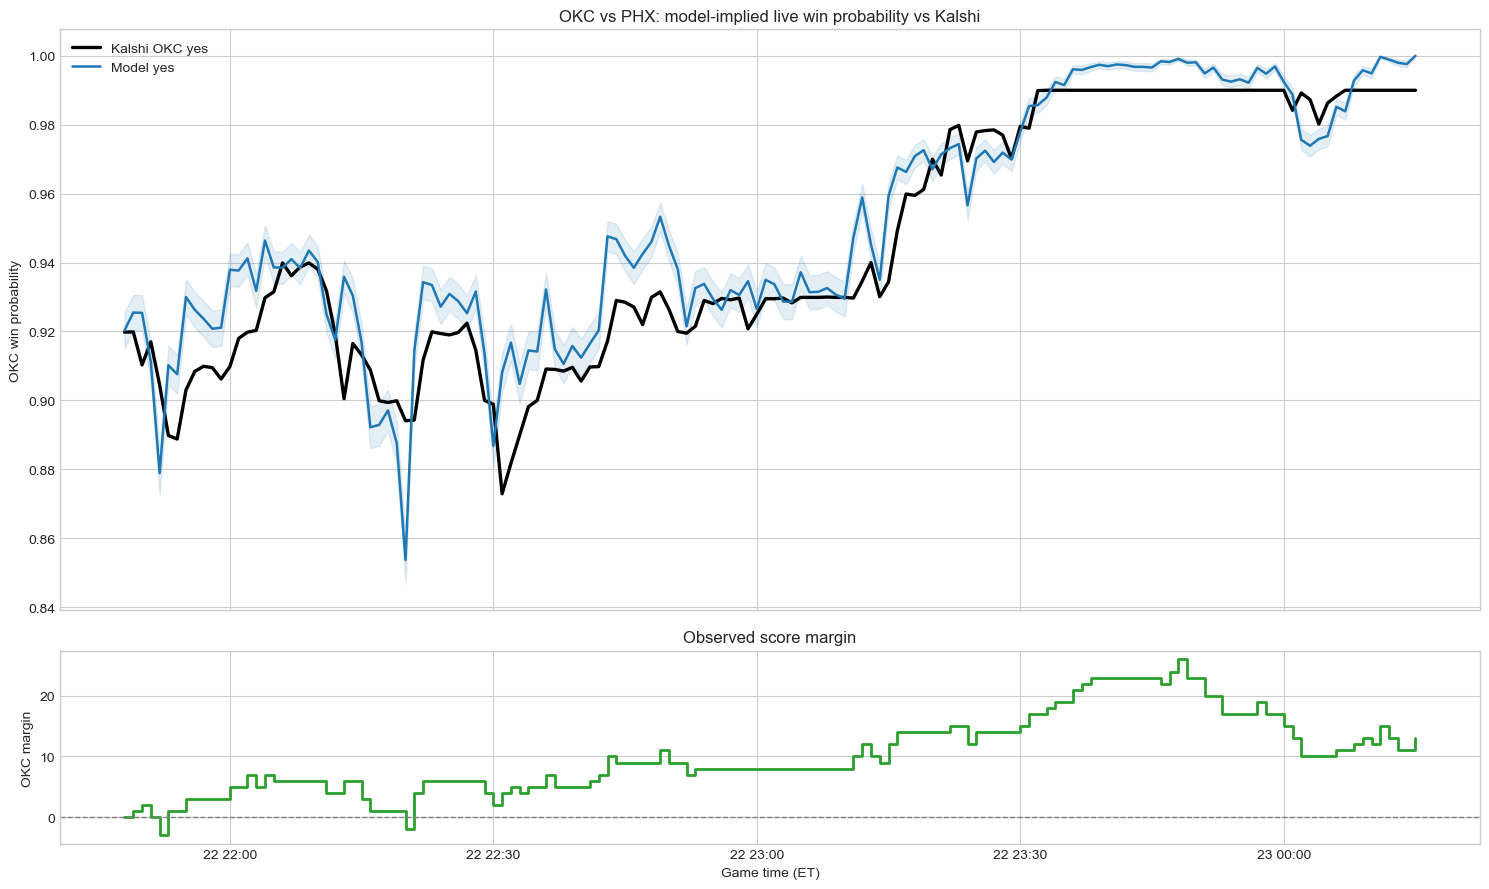

In [42]:
# Final visualization: top panel compares Kalshi's OKC yes price to the model
# fair value; bottom panel shows the observed OKC point margin driving reprices.
fig, axes = plt.subplots(
    2,
    1,
    figsize=(15, 9),
    sharex=True,
    gridspec_kw={"height_ratios": [3, 1]},
)

axes[0].plot(analysis["timestamp_et"], analysis["kalshi_yes_price"], label="Kalshi OKC yes", linewidth=2.4, color="black")
axes[0].plot(analysis["timestamp_et"], analysis["model_fair_yes"], label="Model yes", linewidth=1.8, color="#1f77b4")
# The shaded band is the Monte Carlo 95% confidence interval at each timestamp.
axes[0].fill_between(
    analysis["timestamp_et"],
    analysis["model_ci_low"],
    analysis["model_ci_high"],
    color="#1f77b4",
    alpha=0.12,
)
axes[0].set_ylabel("OKC win probability")
axes[0].set_title("OKC vs PHX: model-implied live win probability vs Kalshi")
axes[0].legend(loc="best")

axes[1].step(analysis["timestamp_et"], analysis["current_margin"], where="post", color="#2ca02c", linewidth=2)
axes[1].axhline(0.0, color="gray", linewidth=1, linestyle="--")
axes[1].set_ylabel("OKC margin")
axes[1].set_title("Observed score margin")

axes[1].set_xlabel("Game time (ET)")

plt.tight_layout()
plt.show()